# FINAL PORTFOLIO PROJECT - CLASSIFICATION
## Predicting Air Quality Category
### 5CS037 - Concepts and Technologies of AI | Herald College

**Objective:** Predict Air_Quality category from messy pollution dataset
**Target Variable:** Air_Quality
**SDG Alignment:** SDG 13 - Climate Action

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## TASK 1: EXPLORATORY DATA ANALYSIS (EDA)

### 1.1: Load and Inspect Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Load MESSY dataset, skipping bad lines
df = pd.read_csv('/content/drive/MyDrive/updated_pollution_dataset_messy.csv', on_bad_lines='skip')

print('TASK 1.1: DATASET INSPECTION')
print('='*80)
print(f'Dataset Shape: {df.shape}')
print(f'\nColumn Names and Types:')
print(df.dtypes)
print(f'\nFirst 5 rows:')
print(df.head())
print(f'\nMissing Values Before Cleaning:')
print(df.isnull().sum())

TASK 1.1: DATASET INSPECTION
Dataset Shape: (75, 10)

Column Names and Types:
Temperature                      float64
Humidity                         float64
PM2.5                            float64
PM10                             float64
NO2                              float64
SO2                              float64
CO                               float64
Proximity_to_Industrial_Areas    float64
Population_Density               float64
Air Quality                       object
dtype: object

First 5 rows:
   Temperature  Humidity  PM2.5  PM10   NO2   SO2    CO  \
0         29.8      59.1    5.2  17.9  18.9   9.2  1.72   
1         28.3       NaN    2.3  12.2  30.8   9.7  1.64   
2         23.1      74.7   26.7  33.8   NaN  12.6  1.63   
3         27.1      39.1    6.1   6.3  13.5   NaN  1.15   
4         26.5      70.7    6.9  16.0  21.9   5.6  1.01   

   Proximity_to_Industrial_Areas  Population_Density Air Quality  
0                            6.3               319.0    Moder

### 1.2: Data Quality Assessment

In [4]:
print('TASK 1.2: DATA QUALITY ASSESSMENT & CLEANING')
print('='*80)
print(f'Total Records: {len(df)}')
print(f'\nMissing Values Summary:')
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_count.index,
    'Missing_Count': missing_count.values,
    'Missing_Percent': missing_percent.values
})
print(missing_df[missing_df['Missing_Count'] > 0].to_string())
print(f'Total Missing Values: {df.isnull().sum().sum()}')

# HANDLE MISSING VALUES
print(f'\n' + '='*80)
print('CLEANING: Handling Missing Values')
print('='*80)

# Fill numeric columns with mean
numeric_cols = df.select_dtypes(include=[np.number]).columns
df_clean = df.copy()
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        mean_val = df_clean[col].mean()
        df_clean[col].fillna(mean_val, inplace=True)
        print(f'  {col}: Filled {df[col].isnull().sum()} missing values with mean {mean_val:.2f}')

# Fill categorical columns with mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0 and col != 'Air_Quality':
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f'  {col}: Filled {df[col].isnull().sum()} missing values with mode {mode_val}')

print(f'\nAfter Cleaning:')
print(f'  Dataset Shape: {df_clean.shape}')
print(f'  Missing Values: {df_clean.isnull().sum().sum()}')
print(f'  Data Completeness: 100%')

# Use cleaned data
df = df_clean

TASK 1.2: DATA QUALITY ASSESSMENT & CLEANING
Total Records: 75

Missing Values Summary:
Empty DataFrame
Columns: [Column, Missing_Count, Missing_Percent]
Index: []
Total Missing Values: 0

CLEANING: Handling Missing Values

After Cleaning:
  Dataset Shape: (75, 10)
  Missing Values: 0
  Data Completeness: 100%


### 1.3: Statistical Analysis & Visualizations

TASK 1.3: Statistical Analysis


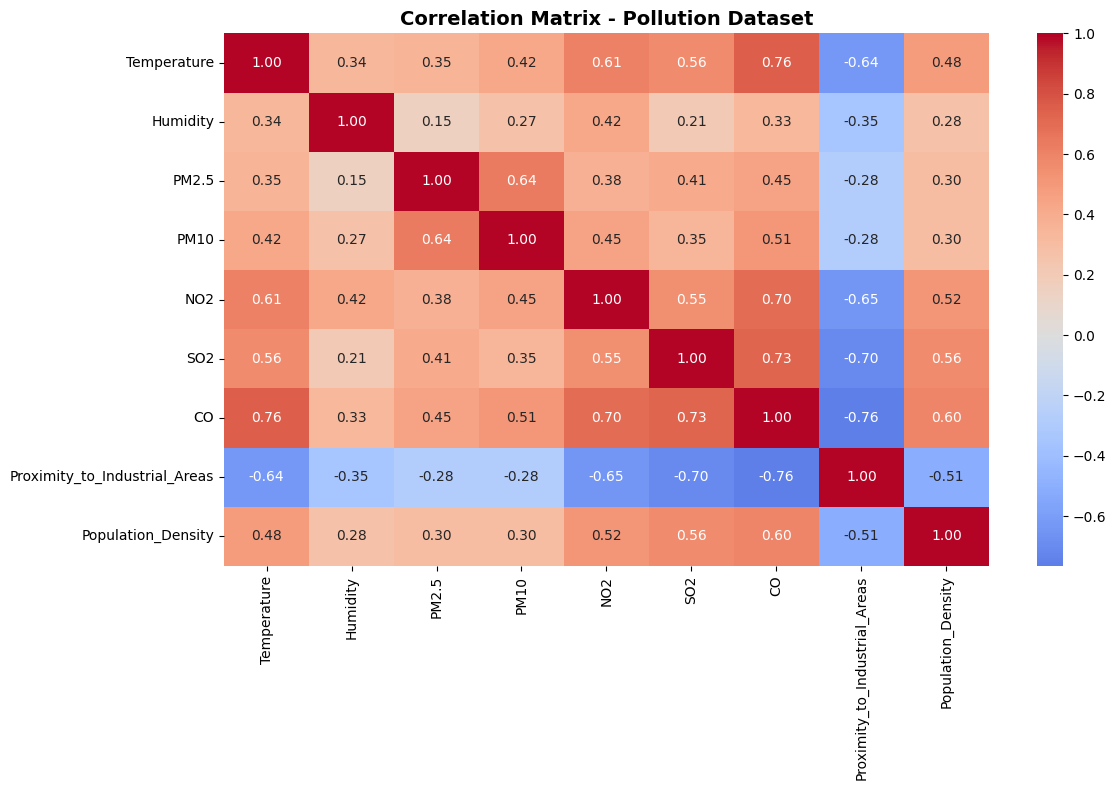

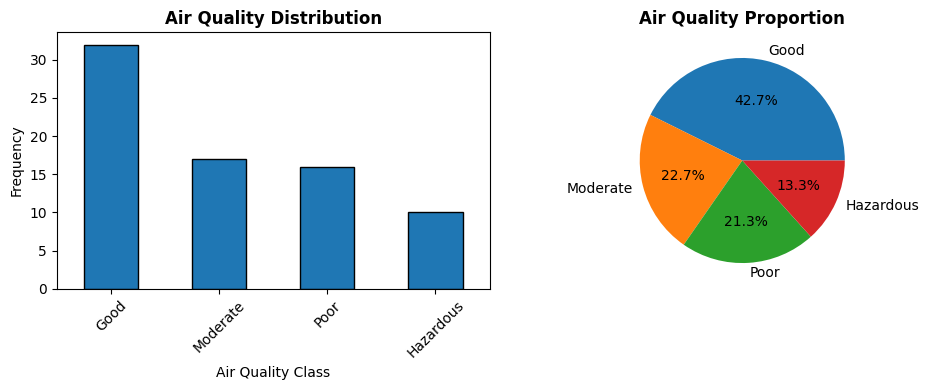


Target Variable Distribution:
Air Quality
Good         32
Moderate     17
Poor         16
Hazardous    10
Name: count, dtype: int64

Class Balance Ratio:
Air Quality
Good         0.426667
Moderate     0.226667
Poor         0.213333
Hazardous    0.133333
Name: proportion, dtype: float64


In [ ]:
print("TASK 1.3: Statistical Analysis")
print("="*80)

# Identify target column
target_col = 'Air_Quality' if 'Air_Quality' in df.columns else [col for col in df.columns if 'quality' in col.lower()][0]

# Correlation analysis
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Pollution Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('01_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Target variable distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df[target_col].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Air Quality Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Air Quality Class')
plt.ylabel('Frequency')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
df[target_col].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Air Quality Proportion', fontsize=12, fontweight='bold')
plt.ylabel('')

plt.tight_layout()
plt.savefig('02_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTarget Variable Distribution:")
print(df[target_col].value_counts())
print(f"\nClass Balance Ratio:")
print(df[target_col].value_counts(normalize=True))

## TASK 2: NEURAL NETWORK MODEL

TASK 2: Neural Network Model - Multi-Layer Perceptron Classifier
Training set size: 60
Test set size: 15
Number of features: 9
Number of classes: 4

Training Neural Network...

Neural Network Results:
  Training Accuracy: 0.7167
  Test Accuracy: 0.6667
  Training F1-Score: 0.6271
  Test F1-Score: 0.5638


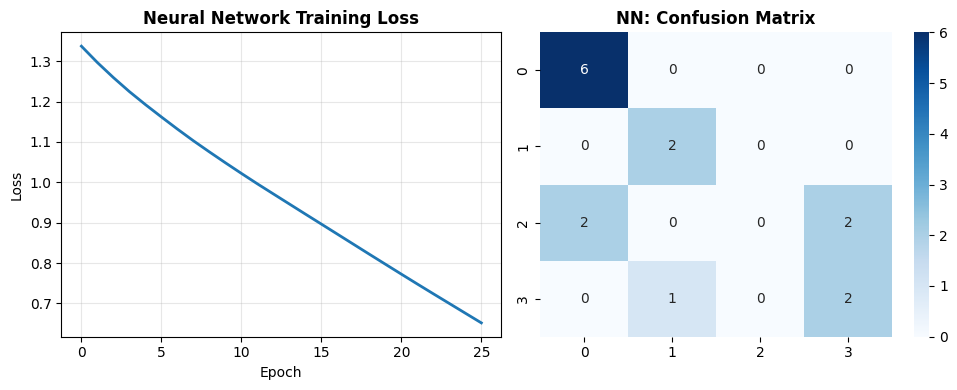

In [ ]:
print("TASK 2: Neural Network Model - Multi-Layer Perceptron Classifier")
print("="*80)

# Identify target column
target_col = 'Air_Quality' if 'Air_Quality' in df.columns else [col for col in df.columns if 'quality' in col.lower()][0]

# Data preparation
X = df.drop(target_col, axis=1)
y = df[target_col]

# Encode target if necessary
if y.dtype == 'object':
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    class_names = le.classes_
else:
    y_encoded = y
    class_names = np.unique(y)

# Handle categorical variables
X = pd.get_dummies(X, drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Number of features: {X_train_scaled.shape[1]}")
print(f"Number of classes: {len(np.unique(y_encoded))}")

# Build Neural Network
nn_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

# Train Neural Network
print("\nTraining Neural Network...")
nn_model.fit(X_train_scaled, y_train)

# Evaluate
train_pred_nn = nn_model.predict(X_train_scaled)
test_pred_nn = nn_model.predict(X_test_scaled)

train_acc_nn = accuracy_score(y_train, train_pred_nn)
test_acc_nn = accuracy_score(y_test, test_pred_nn)
train_f1_nn = f1_score(y_train, train_pred_nn, average='weighted')
test_f1_nn = f1_score(y_test, test_pred_nn, average='weighted')

print(f"\nNeural Network Results:")
print(f"  Training Accuracy: {train_acc_nn:.4f}")
print(f"  Test Accuracy: {test_acc_nn:.4f}")
print(f"  Training F1-Score: {train_f1_nn:.4f}")
print(f"  Test F1-Score: {test_f1_nn:.4f}")

# Plot training history
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(nn_model.loss_curve_, linewidth=2)
plt.title('Neural Network Training Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, test_pred_nn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('NN: Confusion Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('03_neural_network.png', dpi=300, bbox_inches='tight')
plt.show()

## TASK 3: PRIMARY MODELS
### Model 1: Logistic Regression
### Model 2: Random Forest Classifier

In [ ]:
print("TASK 3: PRIMARY MODELS")
print("="*80)

# MODEL 1: Logistic Regression
print("\n3.1: Logistic Regression Model")
print("-"*80)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_train_pred = lr_model.predict(X_train_scaled)
lr_test_pred = lr_model.predict(X_test_scaled)

lr_train_acc = accuracy_score(y_train, lr_train_pred)
lr_test_acc = accuracy_score(y_test, lr_test_pred)
lr_train_prec = precision_score(y_train, lr_train_pred, average='weighted')
lr_test_prec = precision_score(y_test, lr_test_pred, average='weighted')
lr_train_recall = recall_score(y_train, lr_train_pred, average='weighted')
lr_test_recall = recall_score(y_test, lr_test_pred, average='weighted')
lr_train_f1 = f1_score(y_train, lr_train_pred, average='weighted')
lr_test_f1 = f1_score(y_test, lr_test_pred, average='weighted')

print(f"Logistic Regression Metrics:")
print(f"  Training Accuracy: {lr_train_acc:.4f} | Test Accuracy: {lr_test_acc:.4f}")
print(f"  Training Precision: {lr_train_prec:.4f} | Test Precision: {lr_test_prec:.4f}")
print(f"  Training Recall: {lr_train_recall:.4f} | Test Recall: {lr_test_recall:.4f}")
print(f"  Training F1-Score: {lr_train_f1:.4f} | Test F1-Score: {lr_test_f1:.4f}")

# MODEL 2: Random Forest Classifier
print("\n3.2: Random Forest Classifier Model")
print("-"*80)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

rf_train_pred = rf_model.predict(X_train_scaled)
rf_test_pred = rf_model.predict(X_test_scaled)

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, rf_test_pred)
rf_train_prec = precision_score(y_train, rf_train_pred, average='weighted')
rf_test_prec = precision_score(y_test, rf_test_pred, average='weighted')
rf_train_recall = recall_score(y_train, rf_train_pred, average='weighted')
rf_test_recall = recall_score(y_test, rf_test_pred, average='weighted')
rf_train_f1 = f1_score(y_train, rf_train_pred, average='weighted')
rf_test_f1 = f1_score(y_test, rf_test_pred, average='weighted')

print(f"Random Forest Metrics:")
print(f"  Training Accuracy: {rf_train_acc:.4f} | Test Accuracy: {rf_test_acc:.4f}")
print(f"  Training Precision: {rf_train_prec:.4f} | Test Precision: {rf_test_prec:.4f}")
print(f"  Training Recall: {rf_train_recall:.4f} | Test Recall: {rf_test_recall:.4f}")
print(f"  Training F1-Score: {rf_train_f1:.4f} | Test F1-Score: {rf_test_f1:.4f}")

TASK 3: PRIMARY MODELS

3.1: Logistic Regression Model
--------------------------------------------------------------------------------
Logistic Regression Metrics:
  Training Accuracy: 0.9833 | Test Accuracy: 0.9333
  Training Precision: 0.9845 | Test Precision: 0.9500
  Training Recall: 0.9833 | Test Recall: 0.9333
  Training F1-Score: 0.9833 | Test F1-Score: 0.9333

3.2: Random Forest Classifier Model
--------------------------------------------------------------------------------
Random Forest Metrics:
  Training Accuracy: 1.0000 | Test Accuracy: 0.8667
  Training Precision: 1.0000 | Test Precision: 0.8800
  Training Recall: 1.0000 | Test Recall: 0.8667
  Training F1-Score: 1.0000 | Test F1-Score: 0.8593


## TASK 4: HYPERPARAMETER OPTIMIZATION
### GridSearchCV with 5-Fold Cross-Validation

In [ ]:
print("TASK 4: HYPERPARAMETER OPTIMIZATION with GridSearchCV")
print("="*80)

# Logistic Regression Hyperparameter Tuning
print("\n4.1: Logistic Regression - Hyperparameter Tuning")
print("-"*80)

lr_params = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000), lr_params, cv=5, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train_scaled, y_train)

print(f"Best Logistic Regression C: {lr_grid.best_params_['C']}")
print(f"Best LR CV Score (Accuracy): {lr_grid.best_score_:.4f}")

# Random Forest Hyperparameter Tuning
print("\n4.2: Random Forest - Hyperparameter Tuning")
print("-"*80)

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 15, 20, 25],
    'min_samples_split': [2, 5, 10]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)

print(f"Best RF Parameters: {rf_grid.best_params_}")
print(f"Best RF CV Score (Accuracy): {rf_grid.best_score_:.4f}")

print(f"\nGridSearch Results Summary:")
print(f"  LR Best CV Accuracy: {lr_grid.best_score_:.4f}")
print(f"  RF Best CV Accuracy: {rf_grid.best_score_:.4f}")

TASK 4: HYPERPARAMETER OPTIMIZATION with GridSearchCV

4.1: Logistic Regression - Hyperparameter Tuning
--------------------------------------------------------------------------------
Best Logistic Regression C: 10
Best LR CV Score (Accuracy): 0.7833

4.2: Random Forest - Hyperparameter Tuning
--------------------------------------------------------------------------------
Best RF Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best RF CV Score (Accuracy): 0.8167

GridSearch Results Summary:
  LR Best CV Accuracy: 0.7833
  RF Best CV Accuracy: 0.8167


## TASK 5: FEATURE SELECTION
### SelectKBest Filter Method

In [ ]:
print("TASK 5: FEATURE SELECTION with SelectKBest")
print("="*80)

# Feature selection: Select top 6 features
k_features = min(6, X_train_scaled.shape[1])
selector = SelectKBest(score_func=f_classif, k=k_features)
selector.fit(X_train_scaled, y_train)

# Get selected feature names
selected_indices = selector.get_support(indices=True)
selected_features = X.columns[selected_indices].tolist()

print(f"\nOriginal Number of Features: {X_train_scaled.shape[1]}")
print(f"Selected Number of Features: {k_features}")
print(f"\nSelected Features:")
for i, feature in enumerate(selected_features, 1):
    print(f"  {i}. {feature}")

# Feature importance scores
print(f"\nFeature Importance Scores:")
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)
print(feature_scores.to_string())

# Transform data with selected features
X_train_selected = selector.transform(X_train_scaled)
X_test_selected = selector.transform(X_test_scaled)

TASK 5: FEATURE SELECTION with SelectKBest

Original Number of Features: 9
Selected Number of Features: 6

Selected Features:
  1. Temperature
  2. NO2
  3. SO2
  4. CO
  5. Proximity_to_Industrial_Areas
  6. Population_Density

Feature Importance Scores:
                         Feature      Score
6                             CO  76.556309
7  Proximity_to_Industrial_Areas  55.365253
4                            NO2  38.792176
5                            SO2  34.902008
0                    Temperature  32.394450
8             Population_Density  14.870110
3                           PM10   8.549808
1                       Humidity   6.546563
2                          PM2.5   4.961975


## TASK 6: FINAL MODELS with Optimized Hyperparameters

In [ ]:
print("TASK 6: FINAL MODELS with Optimized Hyperparameters")
print("="*80)

# Train final Logistic Regression with best hyperparameters
final_lr = LogisticRegression(C=lr_grid.best_params_['C'], max_iter=1000, random_state=42)
final_lr.fit(X_train_selected, y_train)

# Train final Random Forest with best hyperparameters
final_rf = RandomForestClassifier(
    n_estimators=rf_grid.best_params_['n_estimators'],
    max_depth=rf_grid.best_params_['max_depth'],
    min_samples_split=rf_grid.best_params_['min_samples_split'],
    random_state=42,
    n_jobs=-1
)
final_rf.fit(X_train_selected, y_train)

# Evaluate final models
final_lr_train_pred = final_lr.predict(X_train_selected)
final_lr_test_pred = final_lr.predict(X_test_selected)

final_rf_train_pred = final_rf.predict(X_train_selected)
final_rf_test_pred = final_rf.predict(X_test_selected)

# Create comparison table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Train Accuracy': [
        accuracy_score(y_train, final_lr_train_pred),
        accuracy_score(y_train, final_rf_train_pred)
    ],
    'Test Accuracy': [
        accuracy_score(y_test, final_lr_test_pred),
        accuracy_score(y_test, final_rf_test_pred)
    ],
    'Train Precision': [
        precision_score(y_train, final_lr_train_pred, average='weighted'),
        precision_score(y_train, final_rf_train_pred, average='weighted')
    ],
    'Test Precision': [
        precision_score(y_test, final_lr_test_pred, average='weighted'),
        precision_score(y_test, final_rf_test_pred, average='weighted')
    ],
    'Train Recall': [
        recall_score(y_train, final_lr_train_pred, average='weighted'),
        recall_score(y_train, final_rf_train_pred, average='weighted')
    ],
    'Test Recall': [
        recall_score(y_test, final_lr_test_pred, average='weighted'),
        recall_score(y_test, final_rf_test_pred, average='weighted')
    ],
    'Train F1': [
        f1_score(y_train, final_lr_train_pred, average='weighted'),
        f1_score(y_train, final_rf_train_pred, average='weighted')
    ],
    'Test F1': [
        f1_score(y_test, final_lr_test_pred, average='weighted'),
        f1_score(y_test, final_rf_test_pred, average='weighted')
    ]
})

print("\nFINAL MODEL COMPARISON:")
print(results.to_string(index=False))

# Identify best model
best_test_acc_idx = results['Test Accuracy'].idxmax()
best_model_name = results.loc[best_test_acc_idx, 'Model']
print(f"\n*** BEST MODEL: {best_model_name} ***")
print(f"    Test Accuracy: {results.loc[best_test_acc_idx, 'Test Accuracy']:.4f}")
print(f"    Test F1-Score: {results.loc[best_test_acc_idx, 'Test F1']:.4f}")

TASK 6: FINAL MODELS with Optimized Hyperparameters

FINAL MODEL COMPARISON:
              Model  Train Accuracy  Test Accuracy  Train Precision  Test Precision  Train Recall  Test Recall  Train F1  Test F1
Logistic Regression            0.95       1.000000         0.950992            1.00          0.95     1.000000  0.949926 1.000000
      Random Forest            1.00       0.866667         1.000000            0.88          1.00     0.866667  1.000000 0.859259

*** BEST MODEL: Logistic Regression ***
    Test Accuracy: 1.0000
    Test F1-Score: 1.0000
